C:\Users\user\AppData\Local\Temp\ipykernel_2224\2244631078.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


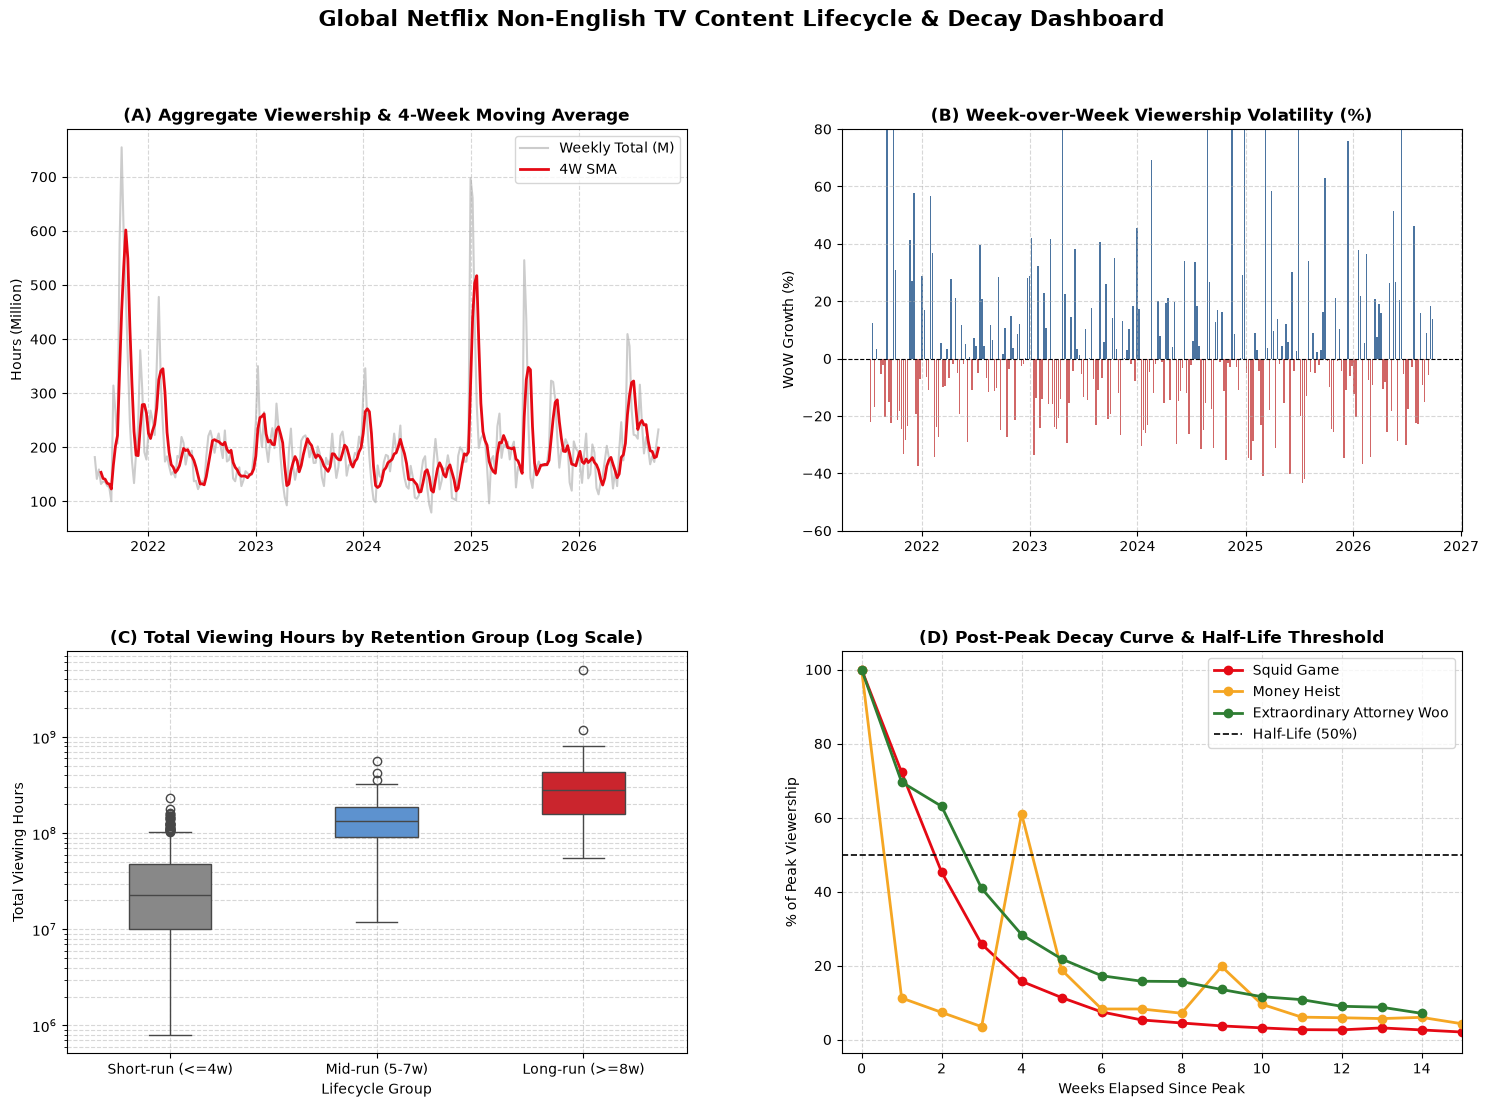

통합 대시보드 저장 완료 -> ../images/00_executive_dashboard.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
weekly_macro = pd.read_csv('../data/processed/01_weekly_macro_series.csv')
weekly_macro['week'] = pd.to_datetime(weekly_macro['week'])
# 12주 이동평균 추가 계산
weekly_macro['hours_sma_12w'] = weekly_macro['weekly_hours_viewed'].rolling(window=12).mean()

show_summary = pd.read_csv('../data/processed/02_show_retention_summary.csv')
df_decay_post = pd.read_csv('../data/processed/03_decay_normalized.csv')

# 2. 2x2 통합 대시보드 생성
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(wspace=0.22, hspace=0.28)

# Panel 1: (A) 거시 추이 & 선 3개 (Raw, 4W SMA, 12W SMA)
ax1 = axes[0, 0]
ax1.plot(weekly_macro['week'], weekly_macro['weekly_hours_viewed'] / 1e6, 
         color='#C0C0C0', alpha=0.6, linewidth=1.0, label='Raw Hours')
ax1.plot(weekly_macro['week'], weekly_macro['hours_sma_4w'] / 1e6, 
         color='#0055FF', linewidth=1.8, label='4W SMA (Blue)')
ax1.plot(weekly_macro['week'], weekly_macro['hours_sma_12w'] / 1e6, 
         color='#E50914', linewidth=2.4, label='12W SMA (Red)')
ax1.set_title('(A) Aggregate Viewership & 3-Line Multi-Span Trend', fontsize=12, fontweight='bold')
ax1.set_ylabel('Hours (Million)')
ax1.legend(loc='upper right', frameon=True, facecolor='white', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel 2: (B) WoW 변동성
ax2 = axes[0, 1]
colors = ['#2b5c8f' if v >= 0 else '#c94c4c' for v in weekly_macro['wow_pct_change']]
ax2.bar(weekly_macro['week'], weekly_macro['wow_pct_change'], color=colors, width=5, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('(B) Week-over-Week Viewership Volatility (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('WoW Growth (%)')
ax2.set_ylim(-60, 80)
ax2.grid(True, linestyle='--', alpha=0.5)

# Panel 3: (C) 롱런작 vs 단기작 분포
ax3 = axes[1, 0]
sns.boxplot(
    data=show_summary, x='lifecycle_group', y='total_hours_viewed',
    order=['Short-run (<=4w)', 'Mid-run (5-7w)', 'Long-run (>=8w)'],
    palette={'Short-run (<=4w)': '#888888', 'Mid-run (5-7w)': '#4A90E2', 'Long-run (>=8w)': '#E50914'},
    ax=ax3, width=0.4
)
ax3.set_yscale('log')
ax3.set_title('(C) Total Viewing Hours by Retention Group (Log Scale)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Lifecycle Group')
ax3.set_ylabel('Total Viewing Hours')
ax3.grid(True, linestyle='--', alpha=0.5, which='both')

# Panel 4: (D) 피크 후 반감기 곡선
ax4 = axes[1, 1]
for show, col in [('Squid Game', '#E50914'), ('Money Heist', '#F5A623'), ('Extraordinary Attorney Woo', '#2E7D32')]:
    sub = df_decay_post[df_decay_post['show_title'] == show]
    ax4.plot(sub['weeks_since_peak'], sub['normalized_pct'], label=show, color=col, marker='o', linewidth=2)
ax4.axhline(50, color='black', linestyle='--', linewidth=1.2, label='Half-Life (50%)')
ax4.set_title('(D) Post-Peak Decay Curve & Half-Life Threshold', fontsize=12, fontweight='bold')
ax4.set_xlabel('Weeks Elapsed Since Peak')
ax4.set_ylabel('% of Peak Viewership')
ax4.set_xlim(-0.5, 15)
ax4.legend(loc='upper right', frameon=True, facecolor='white', fontsize=9)
ax4.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Global Netflix Non-English TV Content Lifecycle & Decay Dashboard', fontsize=15, fontweight='bold', y=0.98)

# 이미지 덮어쓰기 저장
dashboard_path = '../images/00_executive_dashboard.png'
plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"통합 대시보드(선 3개 반영 완료) 저장 완료 -> {dashboard_path}")